<a href="https://colab.research.google.com/github/Karthik-velpula/MLOps/blob/main/Hypermeter_Tunning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install pandas scikit-learn matplotlib joblib mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 647.4 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.6/144.6 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
import time
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42

In [5]:
from google.colab import files
import os

uploaded = files.upload()

uploaded_name = next(iter(uploaded))
DATA_PATH = f"/content/{uploaded_name}"

print("Dataset uploaded:", DATA_PATH)

Saving skill_gap_dataset_realistic.csv to skill_gap_dataset_realistic (1).csv
Dataset uploaded: /content/skill_gap_dataset_realistic (1).csv


In [6]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (100, 6)


,Skill_Name,Curriculum_Coverage,Industry_Demand,Job_Frequency,Expert_Importance,Gap_Status
0,Python,5,5,10,5,Aligned
1,Java,5,4,9,5,Aligned
2,C++,5,3,7,4,Aligned
3,SQL,4,5,9,5,Aligned
4,DBMS,5,4,8,5,Aligned



Columns:
['Skill_Name', 'Curriculum_Coverage', 'Industry_Demand', 'Job_Frequency', 'Expert_Importance', 'Gap_Status']

Missing values:
Skill_Name             0
Curriculum_Coverage    0
Industry_Demand        0
Job_Frequency          0
Expert_Importance      0
Gap_Status             0
dtype: int64


In [7]:
required_columns = [
    "Skill_Name",
    "Curriculum_Coverage",
    "Industry_Demand",
    "Job_Frequency",
    "Expert_Importance",
    "Gap_Status"
]

missing_columns = [c for c in required_columns if c not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("Dataset shape:", df.shape)
display(df.head())

print("\nMissing values:")
print(df[required_columns].isnull().sum())

print("\nTarget distribution:")
print(df["Gap_Status"].value_counts(dropna=False))

Dataset shape: (100, 6)


,Skill_Name,Curriculum_Coverage,Industry_Demand,Job_Frequency,Expert_Importance,Gap_Status
0,Python,5,5,10,5,Aligned
1,Java,5,4,9,5,Aligned
2,C++,5,3,7,4,Aligned
3,SQL,4,5,9,5,Aligned
4,DBMS,5,4,8,5,Aligned



Missing values:
Skill_Name             0
Curriculum_Coverage    0
Industry_Demand        0
Job_Frequency          0
Expert_Importance      0
Gap_Status             0
dtype: int64

Target distribution:
Gap_Status
Aligned    52
Gap        48
Name: count, dtype: int64


In [8]:
feature_columns = [
    "Skill_Name",
    "Curriculum_Coverage",
    "Industry_Demand",
    "Job_Frequency",
    "Expert_Importance"
]

X = df[feature_columns].copy()
y = df["Gap_Status"].copy()

print("Features:", feature_columns)
print("Target: Gap_Status")

Features: ['Skill_Name', 'Curriculum_Coverage', 'Industry_Demand', 'Job_Frequency', 'Expert_Importance']
Target: Gap_Status


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 80
Testing records: 20


In [10]:
numerical_features = [
    "Curriculum_Coverage",
    "Industry_Demand",
    "Job_Frequency",
    "Expert_Importance"
]

categorical_features = [
    "Skill_Name"
]

numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numerical", numerical_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [11]:
baseline_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

baseline_start = time.time()

baseline_pipeline.fit(X_train, y_train)

baseline_runtime = time.time() - baseline_start

baseline_predictions = baseline_pipeline.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print("Baseline test accuracy:", round(baseline_accuracy, 4))
print("Baseline runtime (seconds):", round(baseline_runtime, 2))

print("\nClassification report:")
print(classification_report(y_test, baseline_predictions))

Baseline test accuracy: 0.8
Baseline runtime (seconds): 0.5

Classification report:
              precision    recall  f1-score   support

     Aligned       0.88      0.70      0.78        10
         Gap       0.75      0.90      0.82        10

    accuracy                           0.80        20
   macro avg       0.81      0.80      0.80        20
weighted avg       0.81      0.80      0.80        20



In [12]:
rf_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

number_of_grid_combinations = 1

for values in param_grid.values():
    number_of_grid_combinations *= len(values)

print("Grid combinations:", number_of_grid_combinations)
print("Approximate model fits with 5-fold CV:",
      number_of_grid_combinations * 5)

Grid combinations: 36
Approximate model fits with 5-fold CV: 180


In [13]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_start = time.time()

grid_search.fit(X_train, y_train)

grid_runtime = time.time() - grid_start

print("Best Grid Search parameters:")
print(grid_search.best_params_)

print("Best Grid Search CV accuracy:",
      round(grid_search.best_score_, 4))

print("Grid Search runtime (seconds):",
      round(grid_runtime, 2))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Grid Search parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best Grid Search CV accuracy: 0.9
Grid Search runtime (seconds): 55.51


In [14]:
grid_best_model = grid_search.best_estimator_

grid_predictions = grid_best_model.predict(X_test)

grid_accuracy = accuracy_score(y_test, grid_predictions)

print("Grid Search test accuracy:", round(grid_accuracy, 4))

print("\nClassification report:")
print(classification_report(y_test, grid_predictions))

Grid Search test accuracy: 0.8

Classification report:
              precision    recall  f1-score   support

     Aligned       0.88      0.70      0.78        10
         Gap       0.75      0.90      0.82        10

    accuracy                           0.80        20
   macro avg       0.81      0.80      0.80        20
weighted avg       0.81      0.80      0.80        20



In [15]:
param_distributions = {
    "model__n_estimators": [50, 100, 150, 200, 300, 400],
    "model__max_depth": [None, 3, 5, 8, 10, 15],
    "model__min_samples_split": [2, 4, 6, 8, 10],
    "model__min_samples_leaf": [1, 2, 4, 6],
    "model__max_features": ["sqrt", "log2", None]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    cv=5,
    scoring="accuracy",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

random_start = time.time()

random_search.fit(X_train, y_train)

random_runtime = time.time() - random_start

print("Best Random Search parameters:")
print(random_search.best_params_)

print("Best Random Search CV accuracy:",
      round(random_search.best_score_, 4))

print("Random Search runtime (seconds):",
      round(random_runtime, 2))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Random Search parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 8, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': 3}
Best Random Search CV accuracy: 0.9125
Random Search runtime (seconds): 69.22


In [16]:
random_best_model = random_search.best_estimator_

random_predictions = random_best_model.predict(X_test)

random_accuracy = accuracy_score(
    y_test,
    random_predictions
)

print("Random Search test accuracy:", round(random_accuracy, 4))

print("\nClassification report:")
print(classification_report(y_test, random_predictions))

Random Search test accuracy: 0.85

Classification report:
              precision    recall  f1-score   support

     Aligned       0.89      0.80      0.84        10
         Gap       0.82      0.90      0.86        10

    accuracy                           0.85        20
   macro avg       0.85      0.85      0.85        20
weighted avg       0.85      0.85      0.85        20



In [17]:
comparison_df = pd.DataFrame({
    "Method": ["Baseline", "Grid Search", "Random Search"],
    "CV Accuracy": [
        None,
        grid_search.best_score_,
        random_search.best_score_
    ],
    "Test Accuracy": [
        baseline_accuracy,
        grid_accuracy,
        random_accuracy
    ],
    "Runtime Seconds": [
        baseline_runtime,
        grid_runtime,
        random_runtime
    ]
})

comparison_df["Test Accuracy (%)"] = (
    comparison_df["Test Accuracy"] * 100
)

comparison_df["Improvement vs Baseline (pp)"] = (
    (comparison_df["Test Accuracy"] - baseline_accuracy) * 100
)

display(comparison_df.round(4))

,Method,CV Accuracy,Test Accuracy,Runtime Seconds,Test Accuracy (%),Improvement vs Baseline (pp)
0,Baseline,NaN,0.80,0.4983,80.0,0.0
1,Grid Search,0.9000,0.80,55.5110,80.0,0.0
2,Random Search,0.9125,0.85,69.2234,85.0,5.0


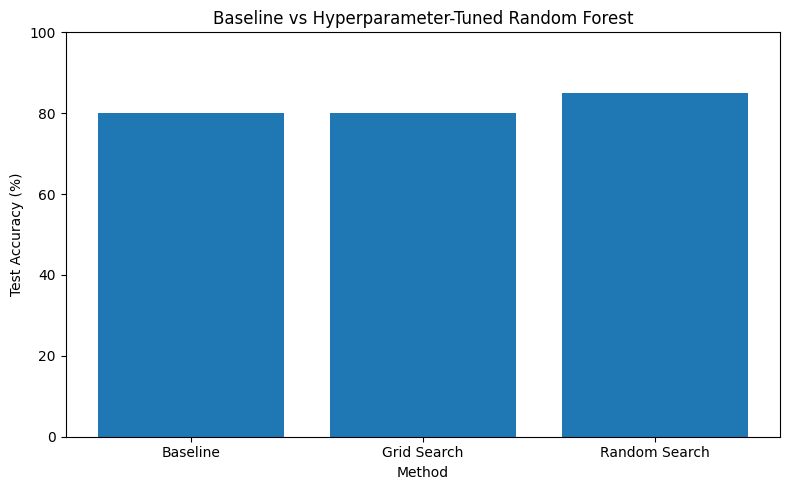

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Method"],
    comparison_df["Test Accuracy (%)"]
)

plt.ylabel("Test Accuracy (%)")
plt.xlabel("Method")
plt.title("Baseline vs Hyperparameter-Tuned Random Forest")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

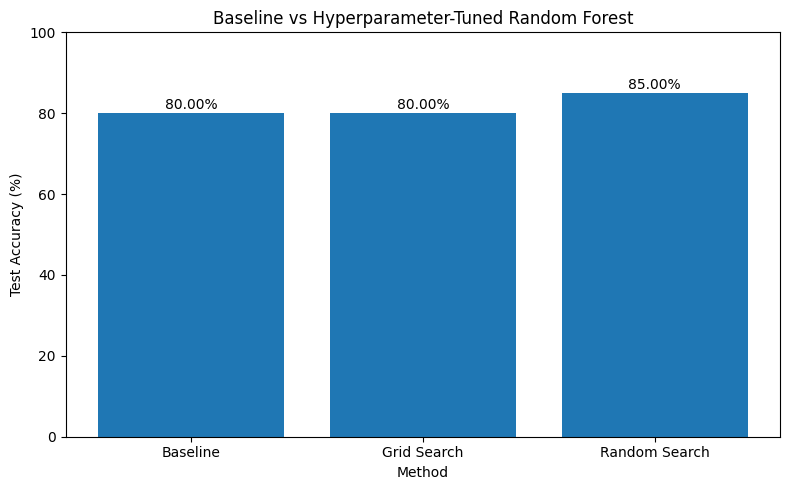

In [19]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    comparison_df["Method"],
    comparison_df["Test Accuracy (%)"]
)

plt.ylabel("Test Accuracy (%)")
plt.xlabel("Method")
plt.title("Baseline vs Hyperparameter-Tuned Random Forest")
plt.ylim(0, 100)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [20]:
grid_results = pd.DataFrame(grid_search.cv_results_)

grid_result_table = grid_results[[
    "param_model__n_estimators",
    "param_model__max_depth",
    "param_model__min_samples_split",
    "param_model__min_samples_leaf",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].copy()

grid_result_table = grid_result_table.sort_values(
    ["rank_test_score", "mean_test_score"],
    ascending=[True, False]
).reset_index(drop=True)

display(grid_result_table.head(10))

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,mean_test_score,std_test_score,rank_test_score
0,200,None,5,1,0.9,0.084779,1
1,200,None,5,2,0.9,0.084779,1
2,50,5,2,1,0.9,0.084779,1
3,100,5,2,1,0.9,0.084779,1
4,50,5,5,1,0.9,0.084779,1
5,100,5,5,1,0.9,0.084779,1
6,100,5,2,2,0.9,0.084779,1
7,100,5,5,2,0.9,0.084779,1
8,100,10,5,1,0.9,0.084779,1
9,200,10,5,1,0.9,0.084779,1


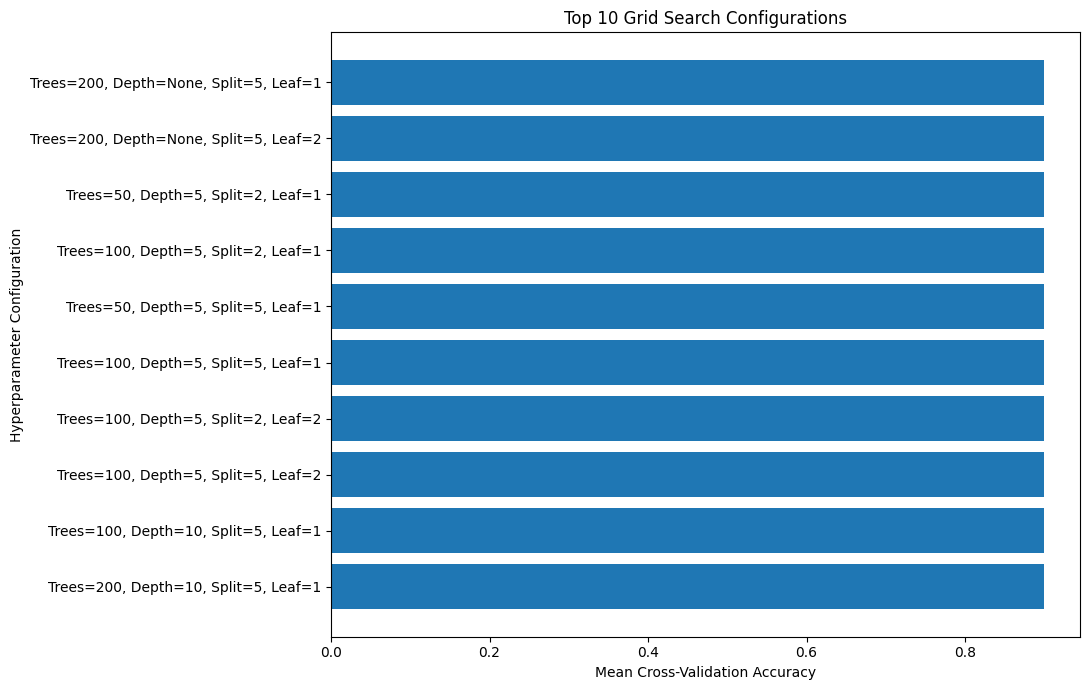

In [21]:
top_grid = grid_result_table.head(10).copy()

top_grid["Configuration"] = (
    "Trees=" + top_grid["param_model__n_estimators"].astype(str)
    + ", Depth=" + top_grid["param_model__max_depth"].astype(str)
    + ", Split=" + top_grid["param_model__min_samples_split"].astype(str)
    + ", Leaf=" + top_grid["param_model__min_samples_leaf"].astype(str)
)
top_grid_plot = top_grid.iloc[::-1]

plt.figure(figsize=(11, 7))

plt.barh(
    top_grid_plot["Configuration"],
    top_grid_plot["mean_test_score"]
)

plt.xlabel("Mean Cross-Validation Accuracy")
plt.ylabel("Hyperparameter Configuration")
plt.title("Top 10 Grid Search Configurations")

plt.tight_layout()
plt.show()

In [22]:
random_results = pd.DataFrame(random_search.cv_results_)

random_result_table = random_results[[
    "param_model__n_estimators",
    "param_model__max_depth",
    "param_model__min_samples_split",
    "param_model__min_samples_leaf",
    "param_model__max_features",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].copy()

random_result_table = random_result_table.sort_values(
    ["rank_test_score", "mean_test_score"],
    ascending=[True, False]
).reset_index(drop=True)

display(random_result_table.head(10))

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,mean_test_score,std_test_score,rank_test_score
0,200,3,8,1,None,0.9125,0.084779,1
1,200,8,2,2,sqrt,0.9000,0.084779,2
2,200,None,6,1,log2,0.9000,0.084779,2
3,200,15,6,2,sqrt,0.9000,0.084779,2
4,150,15,8,1,log2,0.9000,0.084779,2
5,300,8,2,1,log2,0.9000,0.084779,2
6,200,10,6,1,sqrt,0.9000,0.084779,2
7,150,10,10,1,log2,0.9000,0.084779,2
8,200,15,4,2,None,0.8875,0.091856,9
9,150,3,4,4,None,0.8875,0.082916,9


In [23]:
grid_improvement_pp = (grid_accuracy - baseline_accuracy) * 100
random_improvement_pp = (random_accuracy - baseline_accuracy) * 100

print("Baseline test accuracy:      {:.2f}%".format(
    baseline_accuracy * 100
))

print("Grid Search test accuracy:   {:.2f}%".format(
    grid_accuracy * 100
))

print("Random Search test accuracy: {:.2f}%".format(
    random_accuracy * 100
))

print()

print("Grid Search impact:   {:+.2f} percentage points".format(
    grid_improvement_pp
))

print("Random Search impact: {:+.2f} percentage points".format(
    random_improvement_pp
))

if grid_improvement_pp > 0:
    print("Grid Search improved test accuracy.")
elif grid_improvement_pp < 0:
    print("Grid Search reduced test accuracy; the best CV configuration did not generalize better to this test split.")
else:
    print("Grid Search produced no change in test accuracy.")

if random_improvement_pp > 0:
    print("Random Search improved test accuracy.")
elif random_improvement_pp < 0:
    print("Random Search reduced test accuracy; the best CV configuration did not generalize better to this test split.")
else:
    print("Random Search produced no change in test accuracy.")

Baseline test accuracy:      80.00%
Grid Search test accuracy:   80.00%
Random Search test accuracy: 85.00%

Grid Search impact:   +0.00 percentage points
Random Search impact: +5.00 percentage points
Grid Search produced no change in test accuracy.
Random Search improved test accuracy.


In [24]:
model_candidates = {
    "Baseline": (baseline_accuracy, baseline_pipeline),
    "Grid Search": (grid_accuracy, grid_best_model),
    "Random Search": (random_accuracy, random_best_model)
}

best_method = max(
    model_candidates,
    key=lambda name: model_candidates[name][0]
)

final_accuracy, final_model = model_candidates[best_method]

FINAL_MODEL_PATH = "/content/best_skill_gap_random_forest.pkl"

joblib.dump(final_model, FINAL_MODEL_PATH)

print("Selected method:", best_method)
print("Selected test accuracy: {:.2f}%".format(
    final_accuracy * 100
))
print("Saved model:", FINAL_MODEL_PATH)

Selected method: Random Search
Selected test accuracy: 85.00%
Saved model: /content/best_skill_gap_random_forest.pkl


In [25]:
loaded_model = joblib.load(FINAL_MODEL_PATH)

new_skill = pd.DataFrame({
    "Skill_Name": ["Python"],
    "Curriculum_Coverage": [70],
    "Industry_Demand": [95],
    "Job_Frequency": [90],
    "Expert_Importance": [92]
})

prediction = loaded_model.predict(new_skill)[0]

print("Skill:", new_skill["Skill_Name"].iloc[0])
print("Predicted Gap Status:", prediction)

Skill: Python
Predicted Gap Status: Aligned


In [26]:
new_skill = pd.DataFrame({
    "Skill_Name": ["Docker"],
    "Curriculum_Coverage": [50],
    "Industry_Demand": [90],
    "Job_Frequency": [85],
    "Expert_Importance": [88]
})

prediction = loaded_model.predict(new_skill)[0]

print("Skill:", new_skill["Skill_Name"].iloc[0])
print("Predicted Gap Status:", prediction)

Skill: Docker
Predicted Gap Status: Aligned


In [28]:
import mlflow

def log_hpo_run(
    run_name,
    tuning_method,
    model_object,
    test_accuracy,
    cv_accuracy=None,
    best_params=None
):
    with mlflow.start_run(run_name=run_name):

        mlflow.log_param(
            "model",
            "RandomForestClassifier"
        )

        mlflow.log_param(
            "tuning_method",
            tuning_method
        )

        if best_params:
            mlflow.log_params({
                f"best_{k.replace('model__', '')}": v
                for k, v in best_params.items()
            })

        mlflow.log_metric(
            "test_accuracy",
            float(test_accuracy)
        )

        if cv_accuracy is not None:
            mlflow.log_metric(
                "best_cv_accuracy",
                float(cv_accuracy)
            )

        mlflow.sklearn.log_model(
            sk_model=model_object,
            name="model",
            serialization_format="cloudpickle"
        )


# Baseline
log_hpo_run(
    "RF_Baseline",
    "None",
    baseline_pipeline,
    baseline_accuracy
)


# Grid Search
log_hpo_run(
    "RF_GridSearch",
    "GridSearchCV",
    grid_best_model,
    grid_accuracy,
    grid_search.best_score_,
    grid_search.best_params_
)


log_hpo_run(
    "RF_RandomSearch",
    "RandomizedSearchCV",
    random_best_model,
    random_accuracy,
    random_search.best_score_,
    random_search.best_params_
)

print("MLflow runs logged successfully.")

2026/09/21 06:06:12 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/21 06:06:13 INFO mlflow.store.db.utils: Updating database tables
2026/09/21 06:06:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/09/21 06:06:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/09/21 06:06:31 WARNING mlflow

MLflow runs logged successfully.


In [30]:
import mlflow
import pandas as pd

# Get all experiments
experiments = mlflow.search_experiments()

for exp in experiments:
    print("Experiment ID:", exp.experiment_id)
    print("Experiment Name:", exp.name)
    print()

Experiment ID: 0
Experiment Name: Default



In [31]:
import mlflow

runs = mlflow.search_runs(
    experiment_ids=["0"]
)

print("Number of runs:", len(runs))

columns = [
    "tags.mlflow.runName",
    "params.tuning_method",
    "metrics.best_cv_accuracy",
    "metrics.test_accuracy"
]

available_columns = [
    c for c in columns
    if c in runs.columns
]

display(
    runs[available_columns].sort_values(
        "metrics.test_accuracy",
        ascending=False
    )
)

Number of runs: 3


,tags.mlflow.runName,params.tuning_method,metrics.best_cv_accuracy,metrics.test_accuracy
0,RF_RandomSearch,RandomizedSearchCV,0.9125,0.85
1,RF_GridSearch,GridSearchCV,0.9000,0.80
2,RF_Baseline,None,NaN,0.80


In [32]:
mlflow.set_experiment("Skill_Gap_Random_Forest")

2026/09/21 06:10:42 INFO mlflow.tracking.fluent: Experiment with name 'Skill_Gap_Random_Forest' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1789971042802, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1789971042802, lifecycle_stage='active', name='Skill_Gap_Random_Forest', tags={}, trace_location=None, workspace='default'>

In [34]:
experiment = mlflow.get_experiment_by_name(
    "Skill_Gap_Random_Forest"
)

print("Experiment ID:", experiment.experiment_id)
print("Experiment Name:", experiment.name)

Experiment ID: 1
Experiment Name: Skill_Gap_Random_Forest
